# GPT model 

In [1]:
Gpt_config ={
    "vocab_size" : 50527, # vocubulary size
    "context_length" : 1024,
    "emb_dim" : 768 ,
    "num_heads" : 12,
    "num_layer" : 12,
    "drop_rate" : 0.1,
    "qkv_bias"  : False
}

Using this configuration, we will implement a GPT placeholder architecture (DummyGPTModel), as shown in figure. This will provide us with a big-picture view of how
everything fits together and what other components we need to code to assemble the
full GPT model architecture

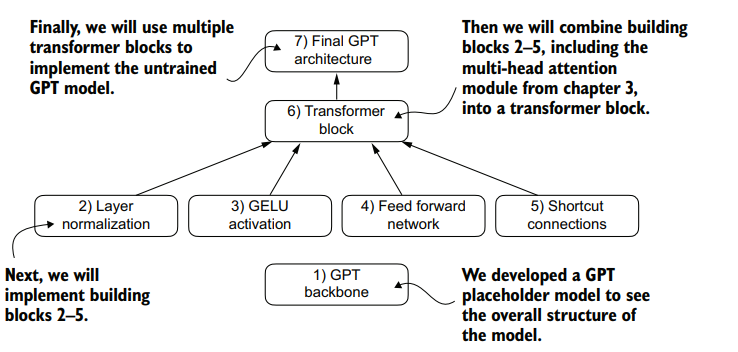

In [2]:
import torch
import torch.nn as nn

In [3]:
# Dummy gpt to show how things works 
class DummyGPTmodel(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"],cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)
              for _ in range(cfg["num_layer"])]
        )
        """
                Uses a placeholder
                for TransformerBlock
        """
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )
        
    def forward(self,in_idx):
        batch_size , seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len,device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        
        return logits
        
        

In [4]:
class DummyTransformerBlock(nn.Module):
    """
        A simple placeholder class that will be
        replaced by a real TransformerBlock later
    """
    
    def __init__(self,cfg):
        super().__init__()
        
    def forward(self,x):
        return x
    
class DummyLayerNorm(nn.Module):
    """
        A simple placeholder class that will be
        replaced by a real LayerNorm later
    """
    
    def __init__(self,Normalized_shape,eps = 1e-5):
        super().__init__()
    
    def forward(self,x):
        return x    

Next, we will prepare the input data and initialize a new GPT model to illustrate
its usage

In [5]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt_1 = "i Will rise Higher"
txt_2 = "learn from your mistake"

batch.append(torch.tensor(tokenizer.encode(txt_1)))
batch.append(torch.tensor(tokenizer.encode(txt_2)))
batch = torch.stack(batch,dim=0)
print(batch)

tensor([[   72,  2561,  4485, 16038],
        [35720,   422,   534,  7457]])


Next, we initialize a new 124-million-parameter DummyGPTModel instance and feed it
the tokenized batch

In [6]:
torch.manual_seed(20)
model = DummyGPTmodel(Gpt_config)
logits = model(batch)
print("output shape:",logits.shape)
print(logits)

output shape: torch.Size([2, 4, 50527])
tensor([[[-0.5773, -0.8839,  0.6876,  ..., -0.2770,  0.0137, -1.1786],
         [-1.2721,  0.2414, -0.5528,  ...,  0.2875, -1.1633,  0.3476],
         [-0.3730, -0.0258, -0.2744,  ...,  0.0033,  0.4225,  0.3412],
         [ 0.2911, -0.6775, -0.5334,  ..., -0.5735, -0.8731, -0.4789]],

        [[-0.3636,  0.1091,  0.6380,  ..., -0.2893, -0.1935, -1.2209],
         [-0.6119,  0.1490, -1.5295,  ...,  0.5687, -0.6480,  0.6093],
         [ 0.0924, -0.1686,  0.6249,  ..., -0.1334,  0.5889,  0.0949],
         [ 1.6205,  0.0628, -0.9647,  ...,  0.4163, -1.2429, -0.7189]]],
       grad_fn=<UnsafeViewBackward0>)


The output tensor has two rows corresponding to the two text samples. Each text sample consists of four tokens; each token is a 50,257-dimensional vector, which matches
the size of the tokenizer’s vocabulary.

Now that we have taken a top-down look at the GPT architecture and its inputs and
outputs, we will code the individual placeholders, starting with the real layer normalization class that will replace the `DummyLayerNorm` in the previous code

## *layer normalization*

The main idea behind layer normalization is to adjust the activations (outputs) of a neural network layer to have a mean of 0 and a variance of 1, also
known as unit variance

$$y_i = \gamma_i \cdot \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta_i, \quad \text{where } \mu = \frac{1}{d}\sum_{i=1}^{d} x_i, \ \ \sigma^2 = \frac{1}{d}\sum_{i=1}^{d}(x_i - \mu)^2$$

* $d$ = `emb_dim`
* $\mu$ = `mean`
* $\sigma^2$ = `var` (note: population variance, divide by $d$ not $d-1$ — that's what `unbiased=False` gives you)
* $\epsilon$ = `self.eps`
* $\hat{x}_i$ = `norm_x`
* $\gamma$ = `self.scale`, $\beta$ = `self.shift`
* $y_i$ = the return value

The variable eps is a small constant (epsilon) added to the variance to prevent division by zero
during normalization

In [7]:
class layerNorm(nn.Module):
    def __init__(self,emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
        
    def forward(self,x):
        mean = x.mean(dim = -1,keepdim = True)
        var = x.var(dim =-1,keepdim = True,unbiased = False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [8]:
ln = layerNorm(emb_dim=5)
batch_example = torch.randn(2, 5) 
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[4.7684e-08],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


## *Implementing a feed forward network with `GELU` activations*
(Gaussian error linear unit)

$$\text{GELU}(x) \approx 0.5x\left(1 + \tanh\left[\sqrt{\frac{2}{\pi}}\left(x + 0.044715x^3\right)\right]\right)$$

In [9]:
# class to implement GELU
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
        
    def forward(self,x):
        return 0.5 * x * (
            1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x,3))
        ))

Next, to get an idea of what this GELU function looks like and how it compares to the
ReLU function, let’s plot these functions side by side

<function matplotlib.pyplot.show(close=None, block=None)>

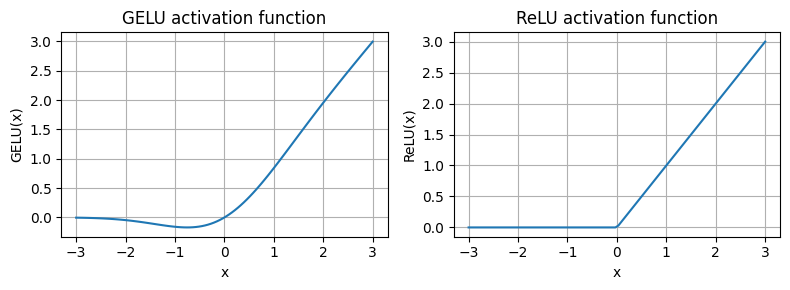

In [10]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
 plt.subplot(1, 2, i)
 plt.plot(x, y)
 plt.title(f"{label} activation function")
 plt.xlabel("x")
 plt.ylabel(f"{label}(x)")
 plt.grid(True)
plt.tight_layout()
plt.show